# Spatial BMCD — pipeline notebook

Clean refactor of `spatial_analysis_original.ipynb`. All function bodies live in:

- [spatial_bmcd/spatial_model.py](spatial_model.py) — single-site integration, spatial Markov step, pairwise composite likelihood, MLE, ECAD I/O.
- [spatial_bmcd/spatial_plotting.py](spatial_plotting.py) — station map, tail-probability illustration, Gaussian-field illustration.
- [spatial_bmcd/spatial_diagnostics.py](spatial_diagnostics.py) — obs-vs-sim diagnostics of the fitted model (block ensembles, spatially ordered rasters, distance-decay statistics).

This notebook reuses the single-site fit outputs produced by [`notebooks_article_pipeline/01_prepare_data_and_fit_distributions.ipynb`](../../article_code/notebooks_article_pipeline/01_prepare_data_and_fit_distributions.ipynb). Equations referenced below are from [spatial_analysis_article.tex](spatial_analysis_article.tex).

It reads top-to-bottom as a single pipeline and uses **one method per task**: the vectorized pairwise `approx_cdf` MLE for estimation, and the Cholesky `simulate_cholesky` for simulation. The technical comparisons that justify those choices — exact vs approximate likelihood kernel, and Cholesky vs scipy/SVD simulator — live in companion notebooks:

- [tests_parameter_estimation.ipynb](tests_parameter_estimation.ipynb) — accuracy & speed of the `approx_cdf` MLE vs the exact `scipy.phi2` baseline, and robustness to missing data.
- [tests_simulation_methods.ipynb](tests_simulation_methods.ipynb) — Cholesky vs scipy/SVD Gaussian draws, and the burn-in choice.
- [diagnostics_fitted_model.ipynb](diagnostics_fitted_model.ipynb) — diagnostics of the fitted model: spatially ordered occurrence rasters, pairwise dependence vs distance, heavy-dry-spell synchrony, wet-fraction and spell-duration checks.

## Imports & data loading

In [2]:
import sys, pathlib
_HERE = pathlib.Path.cwd().resolve()
_REPO_ROOT = next(
    (p for p in (_HERE, *_HERE.parents) if (p / "article_code").is_dir()),
    None,
)
if _REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root containing 'article_code/' from {_HERE}")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from article_code.util_files import config
from spatial_bmcd.archive_old_single_latent_field.spatial_model import (
    prepare_station_fit_table,
    build_dict_model_params,
    run_simulation_mle_experiment,
    load_all_station_rr,
    build_joint_df_occurrence_from_raw_data,
    history_from_Rbin_drop_ambiguous_spell_after_nan,
    split_history_by_year,
    mle_sigma_pairwise,
    mle_sigma_pairwise_histories,
    simulate_cholesky,
)
from spatial_bmcd.archive_old_single_latent_field.spatial_plotting import (
    plot_stations_geomap,
    plot_stations_map,
    plot_tail_probability_illustration,
    plot_gaussian_field_with_thresholds,
)
from spatial_bmcd.archive_old_single_latent_field.spatial_diagnostics import spatial_station_order

In [3]:
# Load single-site outputs produced by notebook 01.
base_filename = (
    f"ecad_data_south_europe_filtered_after_{config.START_YEAR}"
    f"_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json"
)
with open(config.EXPORTS_JSON_DIR / base_filename) as fh:
    spells = json.load(fh)

stations_metadata = pd.read_csv(config.STATION_METADATA_CSV)
stations_used = stations_metadata[stations_metadata["city"].isin(spells.keys())]

fit_folder = (
    config.RESULTS_FIT_DIR
    / f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}"
)
df_fit_dry = pd.read_csv(fit_folder / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv")
df_fit_wet = pd.read_csv(fit_folder / "wet_spell_fit_mixt_geomresult_fit_parameters.csv")
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s: s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s: s.split()[-1])

print(f"{len(spells)} stations in spells JSON; {len(stations_used)} in metadata; "
      f"{df_fit_dry['city'].nunique()} cities in dry fit, "
      f"{df_fit_wet['city'].nunique()} in wet fit")

209 stations in spells JSON; 209 in metadata; 209 cities in dry fit, 209 in wet fit


## Map of cities Europe

Select the Iberian (PT, ES) stations in spring, normalise their coordinates onto $[0,1]^2$ for the spatial covariance, and show them on a map.

In [4]:
COUNTRIES = ["PT", "ES"]
SEASON = "spring"

df_fit_dry_sub, df_fit_wet_sub = prepare_station_fit_table(
    df_fit_dry, df_fit_wet, stations_used,
    countries=COUNTRIES, season=SEASON,
)
print(f"{len(df_fit_dry_sub)} stations kept for season={SEASON}, countries={COUNTRIES}")

plot_stations_geomap(df_fit_dry_sub).show()
# plot_stations_map(df_fit_dry_sub, color_col="xi");

35 stations kept for season=spring, countries=['PT', 'ES']


## Recover exit probabilities from the single-site model

For every station, build the season-specific exit-probability closures $q^{(0)}(d)$ and $q^{(1)}(d)$ using the fitted hdeGPD (dry) and mixture-geometric (wet) parameters and the $f_1$ proportion. See Eq. (1) of the article.

In [5]:
dict_model_params = build_dict_model_params(
    df_fit_dry_sub, df_fit_wet_sub, spells, season=SEASON,
)
print(f"Built model parameters for {len(dict_model_params)} stations")

# Sanity check: q^(0)(1), q^(0)(5), q^(1)(1) for the first station
city0 = next(iter(dict_model_params))
p = dict_model_params[city0]
print(f"{city0}: q_dry(1)={p['q_d_dry_function'](1):.3f}, "
      f"q_dry(5)={p['q_d_dry_function'](5):.3f}, "
      f"q_dry(20)={p['q_d_dry_function'](20):.3f}, --- "
      f"q_wet(1)={p['q_d_wet_function'](1):.3f}",
      f"q_wet(5)={p['q_d_wet_function'](5):.3f}",
      f"q_wet(20)={p['q_d_wet_function'](20):.3f}")

100%|██████████| 35/35 [00:00<00:00, 107.11it/s]

Built model parameters for 35 stations
ALACANT/ALICANTE: q_dry(1)=0.142, q_dry(5)=0.101, q_dry(20)=0.074, --- q_wet(1)=0.538 q_wet(5)=0.521 q_wet(20)=0.441


## Simulation

Implements Section 5 of [main.tex](../Spatialisation-Rain-Occurrence-Generator-article/main.tex#L255). Given a dependence parameter $\sigma$ — either a known *true* value (the sanity check below) or a fitted estimate $\hat\sigma$ (the real-data section) — `simulate_cholesky` produces synthetic spatial trajectories of binary rainfall occurrences as follows:

1. **Spatial Cholesky factorisation** — factor $\boldsymbol{\Sigma}(\sigma) = \mathbf{L}\mathbf{L}^\top$ once.
2. **Initialisation + burn-in** — set $\big(R_0(\mathbf{s}_j), D_0(\mathbf{s}_j)\big) = (0, 1)$ for every $j$ (arbitrary all-dry start), then run and discard $T_\mathrm{burn}$ days (default 500) so the chain reaches its stationary regime.
3. **Sequential update** — for each kept day, draw $\mathbf{V}_n\sim\mathcal{N}(\mathbf{0},\mathbf{I}_J)$, set $\mathbf{Y}_n=\mathbf{L}\mathbf{V}_n$, and apply the threshold rule of Eq. (3).

The returned `history` dict has the same layout as the one produced by `simulate_history`, so it can be fed straight back into `mle_sigma_pairwise` for diagnostics. For an ensemble of $M$ trajectories, call the function $M$ times with different `seed` values.

This notebook uses **only** this Cholesky path. The alternative scipy `multivariate_normal` (SVD) draw and the effect of the burn-in are compared in [tests_simulation_methods.ipynb](tests_simulation_methods.ipynb).

As a first use, we simulate a history with a *known* $\sigma$ and check that the pairwise MLE (next section) recovers it — this validates the simulation scheme itself.

In [6]:
SIGMA_TEST = 0.1
N_STEPS = 1000
N_BURN = 200
SEED = 42

sim_hist = simulate_cholesky(
    sigma=SIGMA_TEST,
    params_by_station=dict_model_params,
    n_steps=N_STEPS,
    n_burn=N_BURN,
    seed=SEED)


## Parameter estimation

The spatial dependence is summarised by a single parameter $\sigma$, estimated by maximising the **pairwise composite likelihood** of the occurrence field (`mle_sigma_pairwise`). The bivariate-normal CDF at the heart of every station pair is evaluated with the vectorized `approx_cdf` kernel (`vectorized=True`): a closed-form, dependency-free port of the Tsay & Ke (2021) approximation that runs over all pairs of a time step at once. Its derivation and accuracy checks live in [approx_cdf_adaptation/approx_cdf_explained.ipynb](../approx_cdf_adaptation/approx_cdf_explained.ipynb).

The estimator is NaN-aware: stations missing on a given day are dropped from that day's pairs. It is validated in [tests_parameter_estimation.ipynb](tests_parameter_estimation.ipynb) — it matches the exact but slow scalar `scipy.phi2` baseline to ~$10^{-5}$ with a large speed-up, and stays unbiased under missing data.

The sanity check above (*Simulation* section) already confirmed that this estimator recovers a known $\sigma$ from a Cholesky-simulated history.


100%|██████████| 6/6 [56:45<00:00, 567.55s/it]


sigma_hat (rows = sigma_true, cols = n_steps):
n_steps     100     1000    10000   20000   50000   100000
sigma_true                                                
0.10        0.1077  0.0964  0.0997  0.0997  0.0997  0.0998
0.25        0.2660  0.2458  0.2480  0.2472  0.2491  0.2493
0.50        0.5314  0.5070  0.4969  0.4980  0.5007  0.4995
0.75        0.7647  0.7413  0.7494  0.7493  0.7523  0.7496
0.90        0.8318  0.8862  0.8957  0.8988  0.9028  0.9006

relative error:
n_steps    100    1000   10000  20000  50000  100000
sigma_true                                          
0.10        7.72%  3.60%  0.30%  0.34%  0.31%  0.20%
0.25        6.38%  1.68%  0.81%  1.13%  0.38%  0.30%
0.50        6.29%  1.40%  0.62%  0.40%  0.15%  0.10%
0.75        1.96%  1.16%  0.08%  0.09%  0.31%  0.06%
0.90        7.57%  1.54%  0.47%  0.13%  0.32%  0.07%


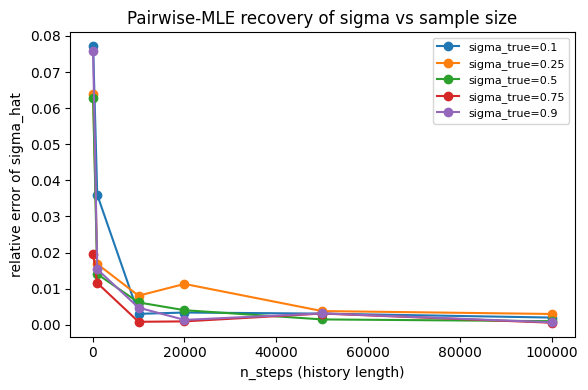

In [6]:
from tqdm import tqdm
# Sanity check: simulate with a known sigma, refit, and check that the pairwise
# MLE recovers it. We sweep a grid of true sigma values x history lengths to see
# how the recovery error behaves with the dependence strength and sample size.
# SIGMA_GRID = [0.1, 0.4, 0.8]
SIGMA_GRID = [0.1, 0.25, 0.5, 0.75, 0.9]
# N_STEPS_GRID = [100, 1000, 10_00, 50_000]
N_STEPS_GRID = [100, 1000, 10_000, 20_000, 50_000,100_000]
N_BURN = 200
SEED = 42

records = []
for sigma_true in SIGMA_GRID:
    for n_steps in tqdm(N_STEPS_GRID):
        sim_hist = simulate_cholesky(
            sigma=sigma_true,
            params_by_station=dict_model_params,
            n_steps=n_steps,
            n_burn=N_BURN,
            seed=SEED,
        )
        mle = mle_sigma_pairwise(
            sim_hist, dict_model_params, bounds=(1e-3, 2.0), vectorized=True
        )
        sigma_hat = mle["sigma_hat"]
        records.append({
            "sigma_true": sigma_true,
            "n_steps": n_steps,
            "sigma_hat": sigma_hat,
            "rel_err": abs(sigma_hat - sigma_true) / sigma_true,
        })

results = pd.DataFrame(records)

# sigma_hat and relative error as sigma_true (rows) x n_steps (cols) tables.
sigma_hat_tbl = results.pivot(index="sigma_true", columns="n_steps", values="sigma_hat")
rel_err_tbl = results.pivot(index="sigma_true", columns="n_steps", values="rel_err")
print("sigma_hat (rows = sigma_true, cols = n_steps):")
print(sigma_hat_tbl.round(4))
print("\nrelative error:")
print(rel_err_tbl.map(lambda v: f"{v:.2%}"))

# Visualise: recovery error vs history length, one line per true sigma.
fig, ax = plt.subplots(figsize=(6, 4))
for sigma_true, grp in results.groupby("sigma_true"):
    ax.plot(grp["n_steps"], grp["rel_err"], marker="o", label=f"sigma_true={sigma_true}")
ax.set_xlabel("n_steps (history length)")
ax.set_ylabel("relative error of sigma_hat")
ax.set_title("Pairwise-MLE recovery of sigma vs sample size")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Real-data estimation on ECAD

Load daily rainfall (`RR`) for every selected station, threshold to dry/wet occurrences, split into per-year histories of one season, and fit a single $\hat{\sigma}$ by summing the pairwise composite likelihood across years.

In [7]:
# Default to the in-repo ECAD subset used by notebook 01.
# Point to a different folder (with the same df_candidates_kept.csv layout) to use new data.
RAW_DATA_DIR = config.ECAD_RAW_DIR
YEAR_MIN, YEAR_MAX = 1980, 2020

stations_to_get = sorted(dict_model_params.keys())
dfs_by_city = load_all_station_rr(
    data_dir=RAW_DATA_DIR, stations_to_get=stations_to_get, verbose=False,
)
stations_to_get = [c for c in stations_to_get if c in dfs_by_city]
print(f"Loaded {len(dfs_by_city)} stations")

Loaded 35 stations


Rbin shape: (3772, 35) (days x stations) over spring 1980-2020


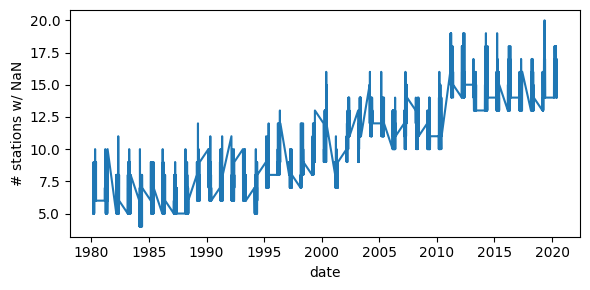

In [8]:
Rbin = build_joint_df_occurrence_from_raw_data(
    dfs_by_city, season=SEASON, station_names=stations_to_get,
    wet_day_threshold=float(config.WET_DAY_THRESHOLD),
)
Rbin = Rbin.loc[(Rbin.index.year >= YEAR_MIN) & (Rbin.index.year <= YEAR_MAX)]
print(f"Rbin shape: {Rbin.shape} (days x stations) over {SEASON} {YEAR_MIN}-{YEAR_MAX}")

# Diagnostic: number of stations with no observation per day
nb_missing = Rbin.isna().sum(axis=1)
plt.figure(figsize=(6, 3))
plt.plot(nb_missing.index, nb_missing.values)
plt.ylabel("# stations w/ NaN"); plt.xlabel("date"); plt.tight_layout();

In [39]:
df_ran_frequency =pd.DataFrame(Rbin.sum(axis=0)/len(Rbin),columns = ["true rain occurrence"]) 

In [41]:
sigma_hat = 0.3197
N_STEPS = 42*90
N_BURN = 1000
SEED = 42

sim_hist = simulate_cholesky(
    sigma=sigma_hat,
    params_by_station=dict_model_params,
    n_steps=N_STEPS,
    n_burn=N_BURN,
    seed=SEED)

sim_hist["R"].sum(axis=0)/len(Rbin)

array([0.16304348, 0.28711559, 0.35100742, 0.21076352, 0.34915164,
       0.37486744, 0.17550371, 0.28234358, 0.12009544, 0.31256628,
       0.34835631, 0.28366914, 0.28844115, 0.19406151, 0.43239661,
       0.37831389, 0.20970308, 0.30514316, 0.15243902, 0.21076352,
       0.13573701, 0.23992577, 0.3504772 , 0.42311771, 0.34358431,
       0.33589608, 0.32635207, 0.33669141, 0.13149523, 0.121421  ,
       0.10577943, 0.18133616, 0.15986214, 0.42895016, 0.26988335])

In [42]:
df_ran_frequency["simulated rain occurrence"] = sim_hist["R"].sum(axis=0)/len(Rbin)

In [52]:
df_ran_frequency.reset_index(inplace=True)

In [56]:
df_ran_frequency#[df_ran_frequency["index"].isin(['TARIFA','CADIZ','HUELVA','TAVIRA','BEJA'])]

,index,true rain occurrence,simulated rain occurrence
0,ALACANT/ALICANTE,0.140244,0.163043
1,ALMEIDINHA,0.134942,0.287116
2,AMARANTE,0.215536,0.351007
3,ARANJUEZ,0.155355,0.210764
4,BARCELOS,0.211294,0.349152
5,BEARIZ,0.206257,0.374867
6,BEJA,0.176564,0.175504
7,BRAGANCA,0.232503,0.282344
8,CADIZ,0.165960,0.120095
9,CAMPDEVANOL,0.305408,0.312566


In [9]:
history = history_from_Rbin_drop_ambiguous_spell_after_nan(Rbin)
histories = split_history_by_year(history)
print(f"{len(histories)} per-year histories (length range: "
      f"{min(h['R'].shape[0] for h in histories)}-{max(h['R'].shape[0] for h in histories)} days)")

41 per-year histories (length range: 92-92 days)


In [10]:
params_by_station = {c: dict_model_params[c] for c in history["station_names"]}
res = mle_sigma_pairwise_histories(histories, params_by_station, bounds=(1e-3, 5.0), vectorized=True)
print(f"sigma_hat = {res['sigma_hat']:.4f}")
print(f"ll_hat    = {res['ll_hat']:.2f}")

sigma_hat = 0.3197
ll_hat    = -710900.98


## Simulation from the fitted real-data model

Re-using the Cholesky simulator introduced above, we now draw a synthetic trajectory from the **real-data fitted model**: the same $J$ stations and $\sigma = \hat\sigma$ from the ECAD MLE. The length $T_\mathrm{sim}$ matches the observation span, and we compare the simulated wet-day frequencies against the observed ones (marginal calibration).

Below are only these two quick checks. The full obs-vs-sim diagnostics battery — spatially ordered occurrence rasters, pairwise dependence vs distance, heavy-dry-spell synchrony, wet-fraction and spell-duration distributions — lives in the companion [diagnostics_fitted_model.ipynb](diagnostics_fitted_model.ipynb).

In [ ]:
# Simulate from the real-data fitted model: same J stations, sigma = sigma_hat
# from the ECAD MLE above. Length T_sim is chosen to match the observation span.
sigma_hat = res["sigma_hat"]
T_sim = Rbin.shape[0]

sim_fit = simulate_cholesky(
    sigma=sigma_hat,
    params_by_station=params_by_station,
    n_steps=T_sim,
    n_burn=500,
    seed=0,
)
print(f"Simulated T_sim={T_sim} days at J={len(sim_fit['station_names'])} stations "
      f"with sigma_hat={sigma_hat:.4f}")

# Diagnostic 1: simulated wet-day frequency vs observed (marginal calibration).
obs_wet_freq = Rbin.mean(axis=0, skipna=True).reindex(sim_fit["station_names"])
sim_wet_freq = pd.Series(
    np.nanmean(sim_fit["R"][1:], axis=0), index=sim_fit["station_names"]
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ax = axes[0]
ax.plot([0, 1], [0, 1], "--", color="grey", lw=0.8)
ax.scatter(obs_wet_freq.values, sim_wet_freq.values, s=22, color="steelblue")
ax.set_xlabel("observed wet-day frequency"); ax.set_ylabel("simulated wet-day frequency")
ax.set_title(f"Marginal calibration  (sigma_hat={sigma_hat:.3f})")
ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Diagnostic 2: a short window of the simulated occurrence trajectory, stations
# ordered by spatial proximity so that coherent wet/dry episodes at nearby
# stations show up as vertically contiguous patches.
ax = axes[1]
preview_days = 120
order = spatial_station_order(params_by_station)
order_idx = [sim_fit["station_names"].index(c) for c in order]
ax.imshow(
    sim_fit["R"][1:preview_days + 1].T[order_idx],
    aspect="auto", cmap="Blues", interpolation="nearest",
)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=6)
ax.set_xlabel("simulated day")
ax.set_title(f"First {preview_days} simulated days (1=wet), spatially ordered")
plt.tight_layout();

## Article figures

Two illustration figures used in `spatial_analysis_article.tex`:

1. The tail-probability transition rule (one panel per regime).
2. The 3-D Gaussian field flipping sign between dry and wet stations — this is the `show_spatial_thresholds_rule.pdf` referenced at line 95 of the LaTeX.

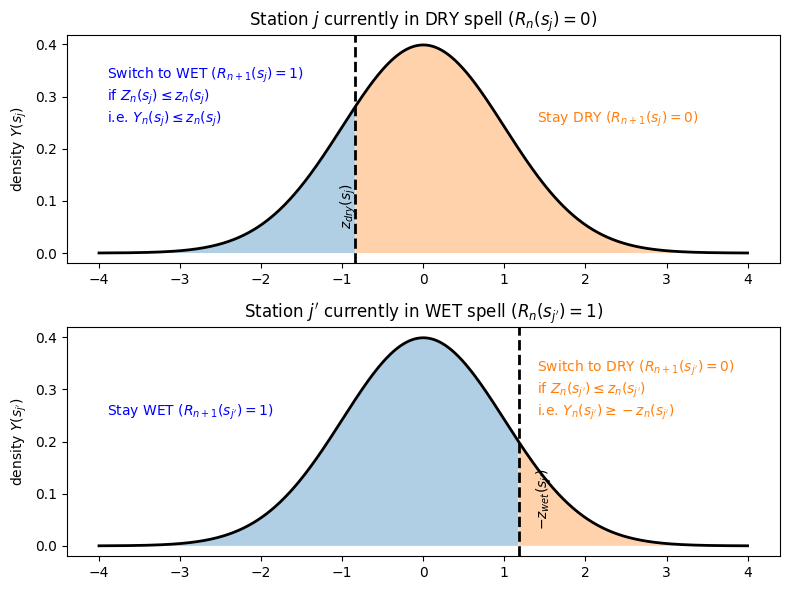

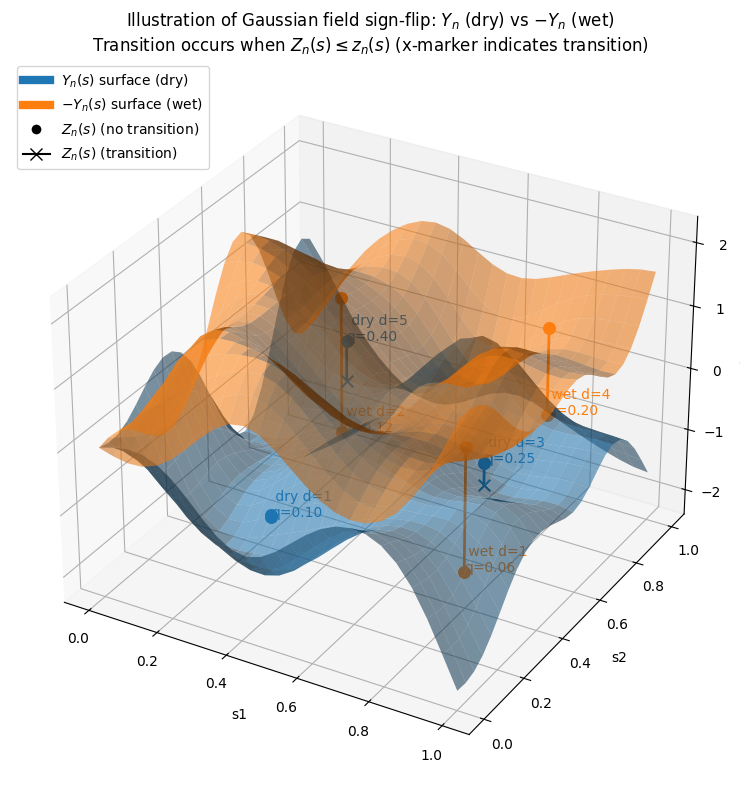

In [11]:
plot_tail_probability_illustration(q_dry=0.20, q_wet=0.12);
plot_gaussian_field_with_thresholds();